In [1]:
import os
print(os.getcwd())

C:\Users\raksh


In [4]:
import pandas as pd

train_data = pd.read_csv(r"C:\Users\raksh\Downloads\train_lyst1717074532669.csv")

train_data.head()

,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,VID_18655,40,1031602,8523,363,1095,2016-09-14,PT7M37S,F
1,VID_14135,2,1707,56,2,6,2016-10-01,PT9M30S,D
2,VID_2187,1,2023,25,0,2,2016-07-02,PT2M16S,C
3,VID_23096,6,620860,777,161,153,2016-07-27,PT4M22S,H
4,VID_10175,1,666,1,0,0,2016-06-29,PT31S,D


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   vidid      14999 non-null  object
 1   adview     14999 non-null  int64 
 2   views      14999 non-null  object
 3   likes      14999 non-null  object
 4   dislikes   14999 non-null  object
 5   comment    14999 non-null  object
 6   published  14999 non-null  object
 7   duration   14999 non-null  object
 8   category   14999 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.0+ MB


In [6]:
train_data.describe()

,adview
count,1.499900e+04
mean,2.107791e+03
std,5.237711e+04
min,1.000000e+00
25%,1.000000e+00
50%,2.000000e+00
75%,6.000000e+00
max,5.429665e+06


In [7]:
train_data.isnull().sum()

vidid        0
adview       0
views        0
likes        0
dislikes     0
comment      0
published    0
duration     0
category     0
dtype: int64

In [8]:
train_data.head(10)

,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,VID_18655,40,1031602,8523,363,1095,2016-09-14,PT7M37S,F
1,VID_14135,2,1707,56,2,6,2016-10-01,PT9M30S,D
2,VID_2187,1,2023,25,0,2,2016-07-02,PT2M16S,C
3,VID_23096,6,620860,777,161,153,2016-07-27,PT4M22S,H
4,VID_10175,1,666,1,0,0,2016-06-29,PT31S,D
5,VID_10756,4,78,0,0,0,2016-05-09,PT15S,D
6,VID_9782,40621,43118,15,1,0,2015-08-21,PT3M20S,D
7,VID_16452,1,14205,55,16,1,2016-08-01,PT58S,E
8,VID_18486,1,526015,3064,211,2582,2015-11-06,PT27M50S,F
9,VID_681,1,406992,3831,310,7839,2016-10-03,PT11M19S,B


In [9]:
train_data = train_data.drop(['vidid'], axis=1)

train_data.head()

,adview,views,likes,dislikes,comment,published,duration,category
0,40,1031602,8523,363,1095,2016-09-14,PT7M37S,F
1,2,1707,56,2,6,2016-10-01,PT9M30S,D
2,1,2023,25,0,2,2016-07-02,PT2M16S,C
3,6,620860,777,161,153,2016-07-27,PT4M22S,H
4,1,666,1,0,0,2016-06-29,PT31S,D


In [10]:
print(train_data['category'].unique())

['F' 'D' 'C' 'H' 'E' 'B' 'G' 'A']


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_data['category'] = le.fit_transform(train_data['category'])

train_data.head()

,adview,views,likes,dislikes,comment,published,duration,category
0,40,1031602,8523,363,1095,2016-09-14,PT7M37S,5
1,2,1707,56,2,6,2016-10-01,PT9M30S,3
2,1,2023,25,0,2,2016-07-02,PT2M16S,2
3,6,620860,777,161,153,2016-07-27,PT4M22S,7
4,1,666,1,0,0,2016-06-29,PT31S,3


In [12]:
print(train_data['category'].unique())

[5 3 2 7 4 1 6 0]


In [13]:
train_data.dtypes

adview        int64
views        object
likes        object
dislikes     object
comment      object
published    object
duration     object
category      int64
dtype: object

In [14]:
cols = ['views', 'likes', 'dislikes', 'comment']

for col in cols:
    train_data[col] = pd.to_numeric(train_data[col], errors='coerce')

train_data.dtypes

adview         int64
views        float64
likes        float64
dislikes     float64
comment      float64
published     object
duration      object
category       int64
dtype: object

In [15]:
train_data.isnull().sum()

adview         0
views          2
likes        155
dislikes     155
comment      233
published      0
duration       0
category       0
dtype: int64

In [16]:
train_data['published'] = pd.to_datetime(train_data['published'])

train_data['year'] = train_data['published'].dt.year
train_data['month'] = train_data['published'].dt.month
train_data['day'] = train_data['published'].dt.day

train_data.head()

,adview,views,likes,dislikes,comment,published,duration,category,year,month,day
0,40,1031602.0,8523.0,363.0,1095.0,2016-09-14,PT7M37S,5,2016,9,14
1,2,1707.0,56.0,2.0,6.0,2016-10-01,PT9M30S,3,2016,10,1
2,1,2023.0,25.0,0.0,2.0,2016-07-02,PT2M16S,2,2016,7,2
3,6,620860.0,777.0,161.0,153.0,2016-07-27,PT4M22S,7,2016,7,27
4,1,666.0,1.0,0.0,0.0,2016-06-29,PT31S,3,2016,6,29


In [18]:
!pip install isodate

In [19]:
import isodate

train_data['duration'] = train_data['duration'].apply(
    lambda x: isodate.parse_duration(x).total_seconds()
)

train_data[['duration']].head()

,duration
0,457.0
1,570.0
2,136.0
3,262.0
4,31.0


In [20]:
train_data = train_data.drop('published', axis=1)

train_data.head()

,adview,views,likes,dislikes,comment,duration,category,year,month,day
0,40,1031602.0,8523.0,363.0,1095.0,457.0,5,2016,9,14
1,2,1707.0,56.0,2.0,6.0,570.0,3,2016,10,1
2,1,2023.0,25.0,0.0,2.0,136.0,2,2016,7,2
3,6,620860.0,777.0,161.0,153.0,262.0,7,2016,7,27
4,1,666.0,1.0,0.0,0.0,31.0,3,2016,6,29


In [21]:
train_data.dtypes

adview        int64
views       float64
likes       float64
dislikes    float64
comment     float64
duration    float64
category      int64
year          int32
month         int32
day           int32
dtype: object

In [22]:
X = train_data.drop('adview', axis=1)
y = train_data['adview']

print(X.shape)
print(y.shape)

(14999, 9)
(14999,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(11999, 9)
(3000, 9)


In [24]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [25]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[2.95500e+01 2.47773e+03 5.36000e+00 4.89000e+00 6.10838e+03 6.95950e+03
 1.06600e+01 4.61000e+00 1.66580e+02 1.44800e+01]


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 4621.101403333333
MSE : 10208599956.223892
RMSE: 101037.61654069187
R2 Score: 0.051162196367281365


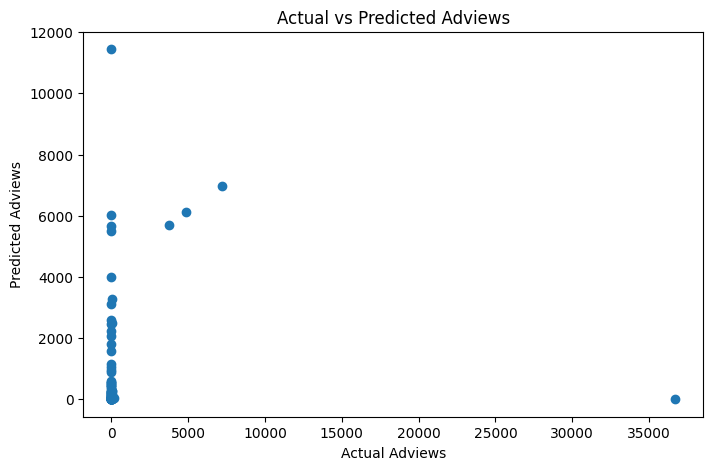

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test[:100], y_pred[:100])
plt.xlabel("Actual Adviews")
plt.ylabel("Predicted Adviews")
plt.title("Actual vs Predicted Adviews")
plt.show()

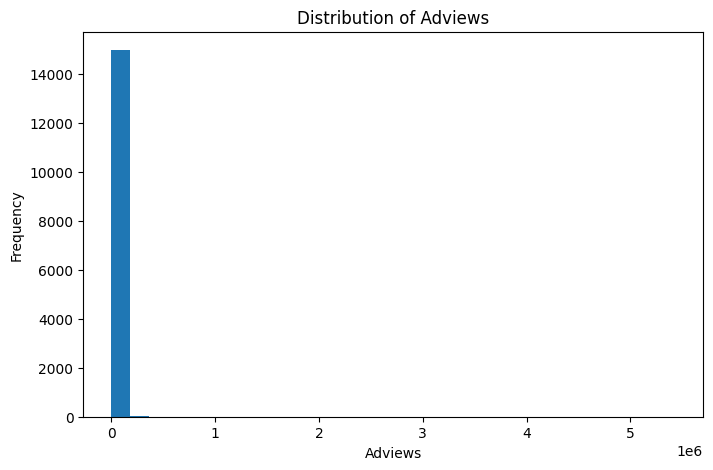

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(train_data['adview'], bins=30)
plt.title("Distribution of Adviews")
plt.xlabel("Adviews")
plt.ylabel("Frequency")
plt.show()

In [3]:
import pandas as pd

train_data = pd.read_csv(
    r"C:\Users\raksh\Downloads\train_lyst1717074532669.csv"
)

print("Dataset loaded successfully!")
print("Shape:", train_data.shape)

train_data.head()

Dataset loaded successfully!
Shape: (14999, 9)


,vidid,adview,views,likes,dislikes,comment,published,duration,category
0,VID_18655,40,1031602,8523,363,1095,2016-09-14,PT7M37S,F
1,VID_14135,2,1707,56,2,6,2016-10-01,PT9M30S,D
2,VID_2187,1,2023,25,0,2,2016-07-02,PT2M16S,C
3,VID_23096,6,620860,777,161,153,2016-07-27,PT4M22S,H
4,VID_10175,1,666,1,0,0,2016-06-29,PT31S,D


In [4]:
print("Duplicate rows:", train_data.duplicated().sum())

train_data = train_data.drop_duplicates()

print("Duplicates removed successfully!")
print("Dataset shape:", train_data.shape)

Duplicate rows: 0
Duplicates removed successfully!
Dataset shape: (14999, 9)


In [5]:
print("Missing values before handling:")
print(train_data.isnull().sum())

# Remove rows containing missing values
train_data = train_data.dropna()

print("\nMissing values after handling:")
print(train_data.isnull().sum())

print("\nDataset shape:", train_data.shape)

Missing values before handling:
vidid        0
adview       0
views        0
likes        0
dislikes     0
comment      0
published    0
duration     0
category     0
dtype: int64

Missing values after handling:
vidid        0
adview       0
views        0
likes        0
dislikes     0
comment      0
published    0
duration     0
category     0
dtype: int64

Dataset shape: (14999, 9)


In [6]:
print("Statistical Summary:")
print(train_data.describe())

Statistical Summary:
             adview
count  1.499900e+04
mean   2.107791e+03
std    5.237711e+04
min    1.000000e+00
25%    1.000000e+00
50%    2.000000e+00
75%    6.000000e+00
max    5.429665e+06


In [7]:
Q1 = train_data['adview'].quantile(0.25)
Q3 = train_data['adview'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = train_data[
    (train_data['adview'] < lower_bound) |
    (train_data['adview'] > upper_bound)
]

print("\nNumber of outliers:", len(outliers))
print("Outlier percentage:",
      (len(outliers) / len(train_data)) * 100)

Q1: 1.0
Q3: 6.0
IQR: 5.0
Lower Bound: -6.5
Upper Bound: 13.5

Number of outliers: 2332
Outlier percentage: 15.547703180212014


In [8]:
import numpy as np

train_data['log_adview'] = np.log1p(train_data['adview'])

print("Original Adview Statistics:")
print(train_data['adview'].describe())

print("\nLog Transformed Adview Statistics:")
print(train_data['log_adview'].describe())

Original Adview Statistics:
count    1.499900e+04
mean     2.107791e+03
std      5.237711e+04
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      6.000000e+00
max      5.429665e+06
Name: adview, dtype: float64

Log Transformed Adview Statistics:
count    14999.000000
mean         1.780293
std          1.917101
min          0.693147
25%          0.693147
50%          1.098612
75%          1.945910
max         15.507388
Name: log_adview, dtype: float64


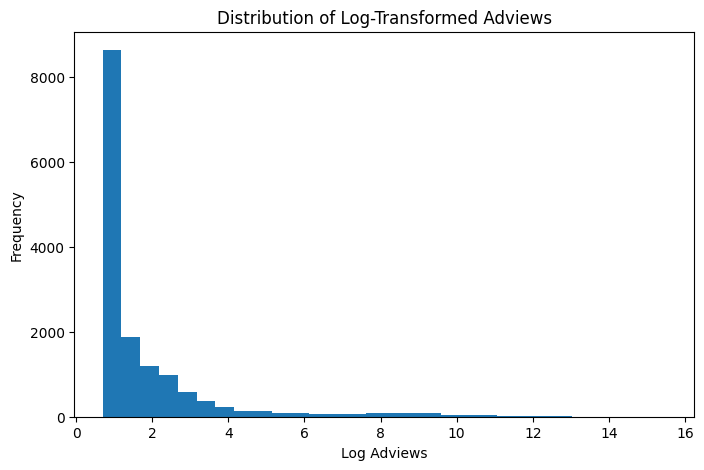

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(train_data['log_adview'], bins=30)

plt.title("Distribution of Log-Transformed Adviews")
plt.xlabel("Log Adviews")
plt.ylabel("Frequency")

plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import isodate

# Remove video ID because it is not useful for prediction
train_data = train_data.drop(
    columns=['vidid'],
    errors='ignore'
)

# Encode category
le = LabelEncoder()
train_data['category'] = le.fit_transform(
    train_data['category']
)

# Convert numeric columns
numeric_cols = [
    'views',
    'likes',
    'dislikes',
    'comment'
]

for col in numeric_cols:
    train_data[col] = pd.to_numeric(
        train_data[col],
        errors='coerce'
    )

# Convert published date
train_data['published'] = pd.to_datetime(
    train_data['published'],
    errors='coerce'
)

# Extract date features
train_data['year'] = train_data['published'].dt.year
train_data['month'] = train_data['published'].dt.month
train_data['day'] = train_data['published'].dt.day

# Convert duration to seconds
train_data['duration'] = train_data['duration'].apply(
    lambda x: isodate.parse_duration(x).total_seconds()
)

# Remove original published column
train_data = train_data.drop(
    columns=['published']
)

# Remove any missing values created during conversion
train_data = train_data.dropna()

print("Preprocessing completed successfully!")
print("\nDataset shape:", train_data.shape)
print("\nData types:")
print(train_data.dtypes)

train_data.head()

Preprocessing completed successfully!

Dataset shape: (14637, 11)

Data types:
adview          int64
views         float64
likes         float64
dislikes      float64
comment       float64
duration      float64
category        int64
log_adview    float64
year            int32
month           int32
day             int32
dtype: object


,adview,views,likes,dislikes,comment,duration,category,log_adview,year,month,day
0,40,1031602.0,8523.0,363.0,1095.0,457.0,5,3.713572,2016,9,14
1,2,1707.0,56.0,2.0,6.0,570.0,3,1.098612,2016,10,1
2,1,2023.0,25.0,0.0,2.0,136.0,2,0.693147,2016,7,2
3,6,620860.0,777.0,161.0,153.0,262.0,7,1.945910,2016,7,27
4,1,666.0,1.0,0.0,0.0,31.0,3,0.693147,2016,6,29


In [11]:
# Input features
X = train_data.drop(
    columns=['adview', 'log_adview']
)

# Target variable
y = train_data['log_adview']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nFeatures used for prediction:")
print(X.columns.tolist())

X Shape: (14637, 9)
y Shape: (14637,)

Features used for prediction:
['views', 'likes', 'dislikes', 'comment', 'duration', 'category', 'year', 'month', 'day']


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (11709, 9)
Testing Features: (2928, 9)
Training Target: (11709,)
Testing Target: (2928,)


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

print("Models created successfully!")

for name in models:
    print("-", name)

Models created successfully!
- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [14]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

trained_models = {}

for name, model in models.items():

    print("Training:", name)

    # Train model
    model.fit(X_train, y_train)

    # Predict log adviews
    y_pred_log = model.predict(X_test)

    # Evaluation on log scale
    mae = mean_absolute_error(
        y_test,
        y_pred_log
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred_log
        )
    )

    r2 = r2_score(
        y_test,
        y_pred_log
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    trained_models[name] = model

    print(name, "completed!\n")

results_df = pd.DataFrame(results)

print("Model Comparison:")
results_df

Training: Linear Regression
Linear Regression completed!

Training: Decision Tree
Decision Tree completed!

Training: Random Forest
Random Forest completed!

Training: Gradient Boosting
Gradient Boosting completed!

Model Comparison:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.191603,1.892226,0.021192
1,Decision Tree,1.301207,2.436818,-0.623295
2,Random Forest,1.017803,1.600414,0.299810
3,Gradient Boosting,1.077014,1.726305,0.185321


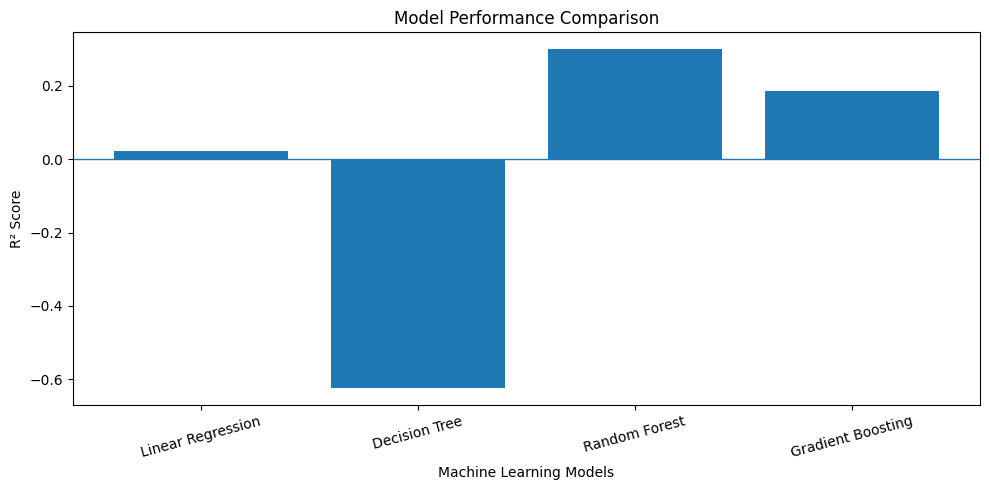

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    results_df['Model'],
    results_df['R2 Score']
)

plt.xlabel("Machine Learning Models")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.xticks(rotation=15)
plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

rf_model = trained_models["Random Forest"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
feature_importance

Feature Importance:


,Feature,Importance
0,views,0.221493
4,duration,0.145499
1,likes,0.131898
2,dislikes,0.111264
3,comment,0.088241
8,day,0.082607
6,year,0.078804
7,month,0.076441
5,category,0.063753


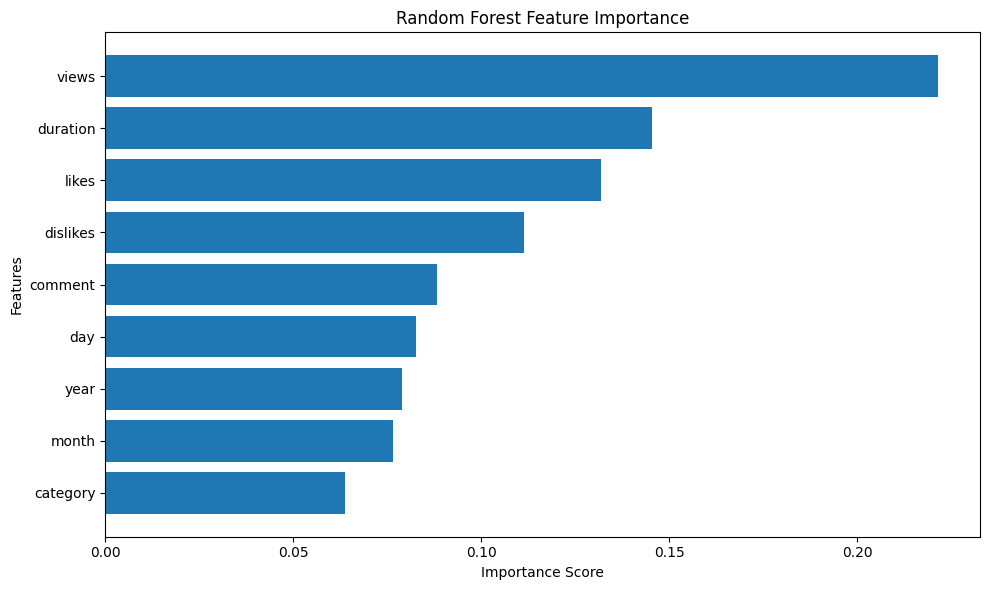

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [18]:
# Engagement rate
train_data['engagement_rate'] = (
    train_data['likes']
    + train_data['dislikes']
    + train_data['comment']
) / (train_data['views'] + 1)

# Like ratio
train_data['like_ratio'] = (
    train_data['likes']
    / (
        train_data['likes']
        + train_data['dislikes']
        + 1
    )
)

# Comment rate
train_data['comment_rate'] = (
    train_data['comment']
    / (train_data['views'] + 1)
)

print("New features added successfully!")

train_data[
    [
        'engagement_rate',
        'like_ratio',
        'comment_rate'
    ]
].head()

New features added successfully!


,engagement_rate,like_ratio,comment_rate
0,0.009675,0.959041,0.001061
1,0.037471,0.949153,0.003513
2,0.013340,0.961538,0.000988
3,0.001757,0.827476,0.000246
4,0.001499,0.500000,0.000000


In [19]:
X = train_data.drop(
    columns=['adview', 'log_adview']
)

y = train_data['log_adview']

print("New X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nUpdated Features:")
print(X.columns.tolist())

New X Shape: (14637, 12)
y Shape: (14637,)

Updated Features:
['views', 'likes', 'dislikes', 'comment', 'duration', 'category', 'year', 'month', 'day', 'engagement_rate', 'like_ratio', 'comment_rate']


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

Training Features: (11709, 12)
Testing Features: (2928, 12)


In [21]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

models_updated = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

updated_results = []
updated_trained_models = {}

for name, model in models_updated.items():

    print("Training:", name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    updated_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    updated_trained_models[name] = model

    print(name, "completed!\n")

updated_results_df = pd.DataFrame(
    updated_results
)

print("Updated Model Comparison:")
updated_results_df

Training: Linear Regression
Linear Regression completed!

Training: Decision Tree
Decision Tree completed!

Training: Random Forest
Random Forest completed!

Training: Gradient Boosting
Gradient Boosting completed!

Updated Model Comparison:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.194098,1.896378,0.016892
1,Decision Tree,1.256118,2.368157,-0.533106
2,Random Forest,1.015897,1.596287,0.303416
3,Gradient Boosting,1.087230,1.734714,0.177365


In [22]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.7, 1.0]
}

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation R2 Score:")
print(random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': None}

Best Cross-Validation R2 Score:
0.22032657540800007


In [23]:
# Get the best tuned model
tuned_rf = random_search.best_estimator_

# Predict on test data
tuned_pred = tuned_rf.predict(X_test)

# Calculate metrics
tuned_mae = mean_absolute_error(
    y_test,
    tuned_pred
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_pred
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_pred
)

print("Tuned Random Forest Performance:")
print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)
print("R2 Score:", tuned_r2)

Tuned Random Forest Performance:
MAE: 1.0003143045180989
RMSE: 1.5937607698482699
R2 Score: 0.30561934606803587


In [24]:
# Convert log values back to original adview scale
actual_adviews = np.expm1(y_test)
predicted_adviews = np.expm1(tuned_pred)

# Prevent negative predictions
predicted_adviews = np.maximum(
    predicted_adviews,
    0
)

print("Converted predictions to original adview scale!")

Converted predictions to original adview scale!


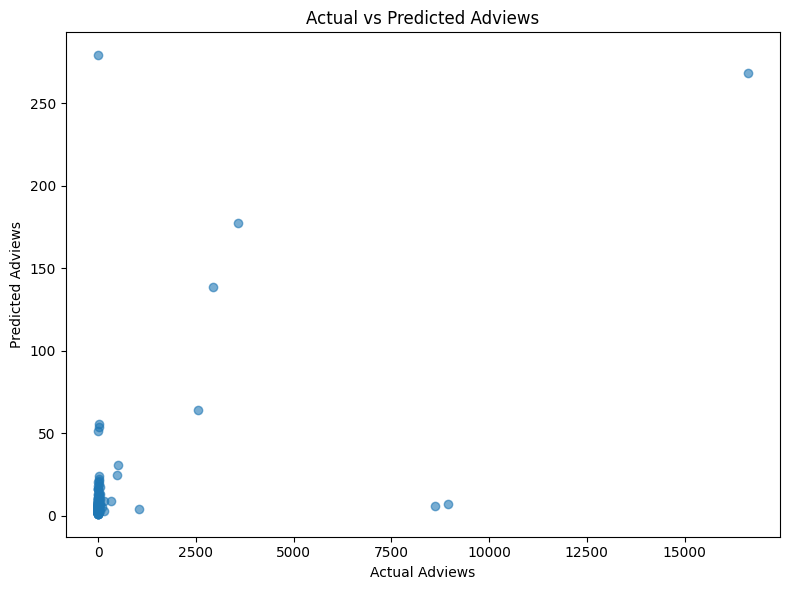

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    actual_adviews[:200],
    predicted_adviews[:200],
    alpha=0.6
)

plt.xlabel("Actual Adviews")
plt.ylabel("Predicted Adviews")
plt.title("Actual vs Predicted Adviews")

plt.tight_layout()
plt.show()


In [26]:
original_mae = mean_absolute_error(
    actual_adviews,
    predicted_adviews
)

original_rmse = np.sqrt(
    mean_squared_error(
        actual_adviews,
        predicted_adviews
    )
)

original_r2 = r2_score(
    actual_adviews,
    predicted_adviews
)

print("Performance on Original Adview Scale:")
print("MAE:", original_mae)
print("RMSE:", original_rmse)
print("R2 Score:", original_r2)

Performance on Original Adview Scale:
MAE: 3474.0305215718677
RMSE: 104356.64828377041
R2 Score: -0.00010061308501030375


In [27]:
comparison_df = pd.DataFrame({
    "Actual_Adviews": actual_adviews,
    "Predicted_Adviews": predicted_adviews
})

comparison_df["Absolute_Error"] = abs(
    comparison_df["Actual_Adviews"]
    - comparison_df["Predicted_Adviews"]
)

comparison_df = comparison_df.sort_values(
    by="Absolute_Error",
    ascending=False
)

print("Worst 20 Predictions:")
comparison_df.head(20)

Worst 20 Predictions:


,Actual_Adviews,Predicted_Adviews,Absolute_Error
9317,5429665.0,84.543754,5.429580e+06
1742,1333626.0,8899.958194,1.324726e+06
1060,453147.0,35.712969,4.531113e+05
5069,439065.0,6.876225,4.390581e+05
9999,271235.0,3.575231,2.712314e+05
13273,220202.0,3.158409,2.201988e+05
7395,187010.0,31.612410,1.869784e+05
14415,143124.0,1374.853667,1.417491e+05
3391,102236.0,1655.113209,1.005809e+05
3569,1.0,99315.705743,9.931471e+04


In [28]:
print("Test Set Actual Adview Statistics:")
print(actual_adviews.describe())

print("\nLargest Actual Adviews in Test Set:")
print(
    actual_adviews
    .sort_values(ascending=False)
    .head(20)
)

Test Set Actual Adview Statistics:
count    2.928000e+03
mean     3.479338e+03
std      1.043692e+05
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      6.000000e+00
max      5.429665e+06
Name: log_adview, dtype: float64

Largest Actual Adviews in Test Set:
9317     5429665.0
1742     1333626.0
1060      453147.0
5069      439065.0
9999      271235.0
13273     220202.0
7395      187010.0
14723     146379.0
14415     143124.0
3391      102236.0
5862       96014.0
6524       75120.0
134        68944.0
13816      65606.0
6974       64985.0
19         53702.0
3177       53500.0
7189       52534.0
8334       37185.0
8168       35981.0
Name: log_adview, dtype: float64


In [29]:
def adview_segment(value):
    if value <= 10:
        return "Low"
    elif value <= 100:
        return "Medium"
    elif value <= 1000:
        return "High"
    else:
        return "Viral"

train_data["adview_segment"] = train_data["adview"].apply(
    adview_segment
)

segment_counts = train_data["adview_segment"].value_counts()

print("Adview Segment Counts:")
print(segment_counts)

print("\nAdview Segment Percentages:")
print(
    train_data["adview_segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Adview Segment Counts:
adview_segment
Low       11990
Medium     1639
Viral       624
High        384
Name: count, dtype: int64

Adview Segment Percentages:
adview_segment
Low       81.92
Medium    11.20
Viral      4.26
High       2.62
Name: proportion, dtype: float64


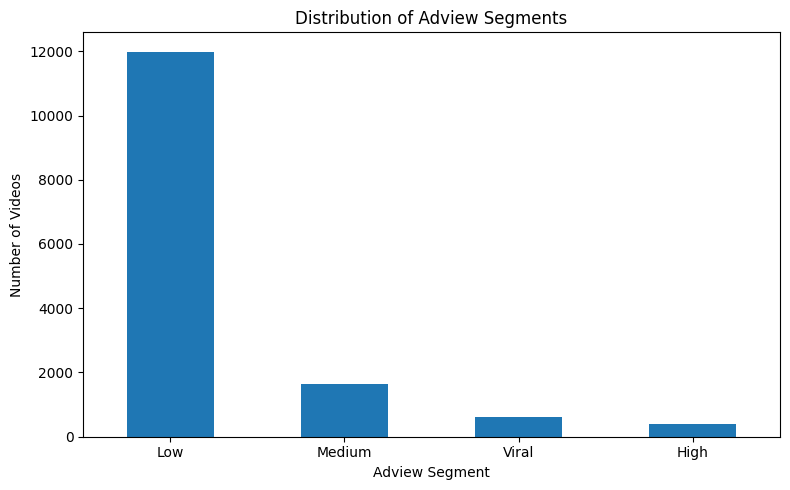

In [30]:
import matplotlib.pyplot as plt

segment_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of Adview Segments")
plt.xlabel("Adview Segment")
plt.ylabel("Number of Videos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

# Classification target
y_class = train_data["adview_segment"]

# Split data for classification
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# Create classifier
segment_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Train classifier
segment_model.fit(
    X_train_cls,
    y_train_cls
)

# Predict
segment_pred = segment_model.predict(
    X_test_cls
)

print("Classification Accuracy:")
print(
    accuracy_score(
        y_test_cls,
        segment_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_cls,
        segment_pred,
        zero_division=0
    )
)

Classification Accuracy:
0.8343579234972678

Classification Report:
              precision    recall  f1-score   support

        High       0.75      0.08      0.14        77
         Low       0.84      0.99      0.91      2398
      Medium       0.59      0.12      0.19       328
       Viral       0.89      0.19      0.32       125

    accuracy                           0.83      2928
   macro avg       0.77      0.34      0.39      2928
weighted avg       0.81      0.83      0.78      2928



In [34]:
from collections import Counter
import pandas as pd

# Combine training features and target
balanced_data = X_train_cls.copy()
balanced_data["adview_segment"] = y_train_cls.values

# Find size of largest class
max_size = balanced_data["adview_segment"].value_counts().max()

# Oversample each class to same size
balanced_parts = []

for class_name, group in balanced_data.groupby("adview_segment"):
    group_resampled = group.sample(
        n=max_size,
        replace=True,
        random_state=42
    )
    balanced_parts.append(group_resampled)

# Combine and shuffle
balanced_data = pd.concat(
    balanced_parts
).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Separate X and y again
X_train_balanced = balanced_data.drop(
    columns=["adview_segment"]
)

y_train_balanced = balanced_data[
    "adview_segment"
]

print("Before Oversampling:")
print(Counter(y_train_cls))

print("\nAfter Oversampling:")
print(Counter(y_train_balanced))

Before Oversampling:
Counter({'Low': 9592, 'Medium': 1311, 'Viral': 499, 'High': 307})

After Oversampling:
Counter({'Medium': 9592, 'Viral': 9592, 'Low': 9592, 'High': 9592})


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

balanced_segment_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

balanced_segment_model.fit(
    X_train_balanced,
    y_train_balanced
)

balanced_pred = balanced_segment_model.predict(
    X_test_cls
)

print("Balanced Classification Accuracy:")
print(
    accuracy_score(
        y_test_cls,
        balanced_pred
    )
)

print("\nBalanced Classification Report:")
print(
    classification_report(
        y_test_cls,
        balanced_pred,
        zero_division=0
    )
)

Balanced Classification Accuracy:
0.819672131147541

Balanced Classification Report:
              precision    recall  f1-score   support

        High       0.41      0.16      0.23        77
         Low       0.86      0.93      0.90      2398
      Medium       0.43      0.31      0.36       328
       Viral       0.67      0.34      0.46       125

    accuracy                           0.82      2928
   macro avg       0.59      0.44      0.49      2928
weighted avg       0.80      0.82      0.80      2928



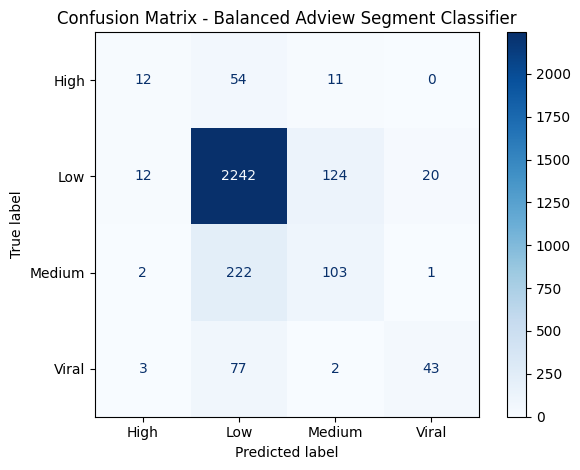

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    balanced_pred,
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Confusion Matrix - Balanced Adview Segment Classifier"
)

plt.tight_layout()
plt.show()

In [41]:
import joblib

# Save tuned regression model
joblib.dump(
    tuned_rf,
    "adview_regression_model.pkl"
)

# Save balanced classification model
joblib.dump(
    balanced_segment_model,
    "adview_segment_classifier.pkl"
)

# Save category encoder
joblib.dump(
    le,
    "category_encoder.pkl"
)

# Save feature column order
joblib.dump(
    X.columns.tolist(),
    "feature_columns.pkl"
)

print("All models and supporting files saved successfully!")

All models and supporting files saved successfully!


In [42]:
import pandas as pd
import numpy as np

# Example new video details
new_video = pd.DataFrame({
    "views": [100000],
    "likes": [5000],
    "dislikes": [200],
    "comment": [800],
    "duration": [300],
    "category": [5],
    "year": [2026],
    "month": [7],
    "day": [4]
})

# Create engineered features
new_video["engagement_rate"] = (
    new_video["likes"]
    + new_video["dislikes"]
    + new_video["comment"]
) / (new_video["views"] + 1)

new_video["like_ratio"] = (
    new_video["likes"]
    / (
        new_video["likes"]
        + new_video["dislikes"]
        + 1
    )
)

new_video["comment_rate"] = (
    new_video["comment"]
    / (new_video["views"] + 1)
)

# Ensure exact same feature order used during training
new_video = new_video[X.columns]

print("New Video Input:")
new_video

New Video Input:


,views,likes,dislikes,comment,duration,category,year,month,day,engagement_rate,like_ratio,comment_rate
0,100000,5000,200,800,300,5,2026,7,4,0.059999,0.961354,0.008


In [43]:
# Predict log adviews
predicted_log_adview = tuned_rf.predict(
    new_video
)[0]

# Convert back to original adview scale
predicted_adview = np.expm1(
    predicted_log_adview
)

# Predict adview segment
predicted_segment = balanced_segment_model.predict(
    new_video
)[0]

print("Prediction Result")
print("-------------------------")
print("Predicted Adviews:", round(predicted_adview))
print("Predicted Segment:", predicted_segment)

Prediction Result
-------------------------
Predicted Adviews: 30
Predicted Segment: Low


In [44]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles in Current Folder:")
for file in os.listdir():
    if file.endswith(".pkl"):
        print(file)

Current Folder:
C:\Users\raksh

Files in Current Folder:
adview_regression_model.pkl
adview_segment_classifier.pkl
category_encoder.pkl
feature_columns.pkl


In [58]:
import subprocess
import sys
import time
import webbrowser

process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.headless=true",
        "--server.port=8501"
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(5)

webbrowser.open("http://localhost:8501")

print("App opened successfully!")

App opened successfully!


In [59]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "-m", "streamlit", "--version"],
    capture_output=True,
    text=True
)

print("OUTPUT:", result.stdout)
print("ERROR:", result.stderr)
print("RETURN CODE:", result.returncode)

OUTPUT: Streamlit, version 1.45.1

ERROR: 
RETURN CODE: 0


In [60]:
import os
import sys
import subprocess
import time
import webbrowser

p = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        os.path.abspath("app.py"),
        "--server.headless=true",
        "--server.port=8501"
    ]
)

time.sleep(5)
print("Server started:", p.poll() is None)
print("Open: http://localhost:8501")

webbrowser.open_new_tab("http://localhost:8501")

Server started: False
Open: http://localhost:8501


True

In [66]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from datetime import date

# =========================================================
# PAGE CONFIG
# =========================================================
st.set_page_config(
    page_title="AdVision AI",
    page_icon="📈",
    layout="wide",
    initial_sidebar_state="expanded"
)

# =========================================================
# LOAD MODELS
# =========================================================
@st.cache_resource
def load_models():
    regression_model = joblib.load("adview_regression_model.pkl")
    segment_model = joblib.load("adview_segment_classifier.pkl")
    category_encoder = joblib.load("category_encoder.pkl")
    feature_columns = joblib.load("feature_columns.pkl")

    return (
        regression_model,
        segment_model,
        category_encoder,
        feature_columns
    )


try:
    (
        regression_model,
        segment_model,
        category_encoder,
        feature_columns
    ) = load_models()

except Exception as e:
    st.error(f"Model loading error: {e}")
    st.info(
        "Make sure all 4 model files are in the same folder as app.py"
    )
    st.stop()


# =========================================================
# CUSTOM CSS
# =========================================================
st.markdown(
    """
    <style>

    /* Main App */
    .stApp {
        background:
            radial-gradient(
                circle at top right,
                rgba(239, 68, 68, 0.08),
                transparent 28%
            ),
            #f7f8fc;
    }

    /* Main Container */
    .block-container {
        max-width: 1250px;
        padding-top: 1.5rem;
        padding-bottom: 3rem;
    }

    /* Hide Streamlit UI */
    #MainMenu {
        visibility: hidden;
    }

    footer {
        visibility: hidden;
    }

    /* Sidebar */
    section[data-testid="stSidebar"] {
        background: #111827;
    }

    section[data-testid="stSidebar"] p,
    section[data-testid="stSidebar"] label,
    section[data-testid="stSidebar"] h1,
    section[data-testid="stSidebar"] h2,
    section[data-testid="stSidebar"] h3 {
        color: white;
    }

    /* Hero */
    .hero {
        padding: 55px 50px;
        border-radius: 24px;
        background:
            linear-gradient(
                135deg,
                #111827 0%,
                #1f2937 55%,
                #7f1d1d 100%
            );
        color: white;
        margin-bottom: 28px;
        box-shadow:
            0 20px 50px rgba(15, 23, 42, 0.15);
    }

    .hero-badge {
        display: inline-block;
        padding: 7px 14px;
        border-radius: 999px;
        background: rgba(255, 255, 255, 0.12);
        border: 1px solid rgba(255, 255, 255, 0.18);
        font-size: 13px;
        margin-bottom: 18px;
        letter-spacing: 0.5px;
    }

    .hero-title {
        font-size: 52px;
        line-height: 1.08;
        font-weight: 800;
        letter-spacing: -1.5px;
        margin-bottom: 16px;
        color: white;
    }

    .hero-text {
        max-width: 780px;
        font-size: 18px;
        line-height: 1.7;
        color: #d1d5db;
    }

    /* Section */
    .section-title {
        font-size: 30px;
        font-weight: 800;
        color: #111827;
        margin-top: 15px;
        margin-bottom: 5px;
    }

    .section-subtitle {
        color: #6b7280;
        font-size: 15px;
        margin-bottom: 22px;
    }

    /* Metric Cards */
    .metric-card {
        background: white;
        padding: 24px;
        border-radius: 18px;
        border: 1px solid #e5e7eb;
        box-shadow:
            0 8px 25px rgba(15, 23, 42, 0.05);
        min-height: 145px;
    }

    .metric-icon {
        font-size: 25px;
        margin-bottom: 12px;
    }

    .metric-value {
        font-size: 29px;
        font-weight: 800;
        color: #111827;
    }

    .metric-label {
        color: #6b7280;
        font-size: 14px;
        margin-top: 5px;
    }

    /* Info Cards */
    .info-card {
        background: white;
        padding: 25px;
        border-radius: 18px;
        border: 1px solid #e5e7eb;
        min-height: 210px;
        box-shadow:
            0 8px 25px rgba(15, 23, 42, 0.04);
    }

    .info-card h3 {
        margin-top: 5px;
        color: #111827;
    }

    .info-card p {
        color: #6b7280;
        line-height: 1.65;
    }

    /* Result Cards */
    .result-card {
        background:
            linear-gradient(
                145deg,
                #ffffff,
                #f8fafc
            );
        padding: 32px;
        border-radius: 20px;
        border: 1px solid #e5e7eb;
        text-align: center;
        box-shadow:
            0 12px 35px rgba(15, 23, 42, 0.08);
        min-height: 170px;
    }

    .result-value {
        font-size: 44px;
        font-weight: 900;
        color: #111827;
    }

    .result-label {
        color: #6b7280;
        font-size: 15px;
        margin-top: 8px;
    }

    .segment-badge {
        display: inline-block;
        padding: 10px 22px;
        border-radius: 999px;
        background: #fee2e2;
        color: #b91c1c;
        font-weight: 800;
        font-size: 20px;
        margin-top: 10px;
    }

    /* Workflow */
    .workflow-step {
        background: white;
        border-left: 4px solid #ef4444;
        padding: 18px 20px;
        margin-bottom: 12px;
        border-radius: 10px;
        border-top: 1px solid #e5e7eb;
        border-right: 1px solid #e5e7eb;
        border-bottom: 1px solid #e5e7eb;
    }

    .workflow-number {
        font-weight: 800;
        color: #ef4444;
    }

    /* Footer */
    .custom-footer {
        margin-top: 50px;
        padding: 28px;
        text-align: center;
        color: #6b7280;
        border-top: 1px solid #e5e7eb;
        line-height: 1.7;
    }

    /* Button */
    .stButton > button {
        border-radius: 12px;
        min-height: 50px;
        font-weight: 700;
    }

    </style>
    """,
    unsafe_allow_html=True
)


# =========================================================
# SIDEBAR
# =========================================================
with st.sidebar:
    st.markdown("## 📈 AdVision AI")

    st.caption(
        "Intelligent YouTube Advertisement "
        "View Prediction Platform"
    )

    st.divider()

    page = st.radio(
        "Navigation",
        [
            "🏠 Overview",
            "🎯 Predict",
            "📊 Model Insights",
            "🧠 How It Works",
            "ℹ️ About Project"
        ]
    )

    st.divider()

    st.markdown("### Model Status")
    st.success("● Models Loaded")

    st.markdown("### Engine")
    st.write("Random Forest")

    st.markdown("### Features")
    st.write(f"{len(feature_columns)} Predictive Features")


# =========================================================
# OVERVIEW PAGE
# =========================================================
if page == "🏠 Overview":

    hero_html = """
<div class="hero">
<div class="hero-badge">MACHINE LEARNING • PREDICTIVE ANALYTICS</div>
<div class="hero-title">Predict YouTube Adviews<br>with Machine Learning</div>
<div class="hero-text">AdVision AI analyzes video engagement, publishing patterns, and audience interaction signals to estimate advertisement views and classify expected video performance.</div>
</div>
"""

    st.markdown(
        hero_html,
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="section-title">Platform Overview</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        """
        <div class="section-subtitle">
            A complete machine learning pipeline from raw data
            to real-time web predictions.
        </div>
        """,
        unsafe_allow_html=True
    )

    c1, c2, c3, c4 = st.columns(4)

    with c1:
        st.markdown(
            """
            <div class="metric-card">
                <div class="metric-icon">🗂️</div>
                <div class="metric-value">14,637</div>
                <div class="metric-label">
                    Processed video records
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )

    with c2:
        st.markdown(
            f"""
            <div class="metric-card">
                <div class="metric-icon">⚙️</div>
                <div class="metric-value">
                    {len(feature_columns)}
                </div>
                <div class="metric-label">
                    Predictive input features
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )

    with c3:
        st.markdown(
            """
            <div class="metric-card">
                <div class="metric-icon">🤖</div>
                <div class="metric-value">2</div>
                <div class="metric-label">
                    Integrated ML models
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )

    with c4:
        st.markdown(
            """
            <div class="metric-card">
                <div class="metric-icon">🎯</div>
                <div class="metric-value">4</div>
                <div class="metric-label">
                    Performance segments
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )

    st.write("")
    st.write("")

    st.markdown(
        '<div class="section-title">Core Capabilities</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        """
        <div class="section-subtitle">
            Designed as an end-to-end intelligent prediction system.
        </div>
        """,
        unsafe_allow_html=True
    )

    a, b, c = st.columns(3)

    with a:
        st.markdown(
            """
            <div class="info-card">
                <h3>📈 Adview Estimation</h3>
                <p>
                    Predicts advertisement view potential using
                    a tuned Random Forest regression pipeline
                    trained on log-transformed target values.
                </p>
            </div>
            """,
            unsafe_allow_html=True
        )

    with b:
        st.markdown(
            """
            <div class="info-card">
                <h3>🏷️ Segment Classification</h3>
                <p>
                    Classifies expected performance into Low,
                    Medium, High, or Viral segments using a
                    balanced classification workflow.
                </p>
            </div>
            """,
            unsafe_allow_html=True
        )

    with c:
        st.markdown(
            """
            <div class="info-card">
                <h3>🧪 Feature Engineering</h3>
                <p>
                    Generates engagement rate, like ratio,
                    and comment rate to capture interaction
                    quality beyond simple raw counts.
                </p>
            </div>
            """,
            unsafe_allow_html=True
        )


# =========================================================
# PREDICT PAGE
# =========================================================
elif page == "🎯 Predict":

    st.markdown(
        """
        <div class="section-title">
            Real-Time Adview Prediction
        </div>
        """,
        unsafe_allow_html=True
    )

    st.markdown(
        """
        <div class="section-subtitle">
            Enter video statistics below. The system automatically
            creates engineered features before prediction.
        </div>
        """,
        unsafe_allow_html=True
    )

    with st.container(border=True):

        st.subheader("Video Performance Inputs")

        col1, col2 = st.columns(2)

        with col1:
            views = st.number_input(
                "Total Views",
                min_value=0,
                value=100000,
                step=1000
            )

            likes = st.number_input(
                "Total Likes",
                min_value=0,
                value=5000,
                step=100
            )

            comments = st.number_input(
                "Total Comments",
                min_value=0,
                value=800,
                step=10
            )

        with col2:
            dislikes = st.number_input(
                "Total Dislikes",
                min_value=0,
                value=200,
                step=10
            )

            duration = st.number_input(
                "Video Duration (seconds)",
                min_value=1,
                value=300,
                step=10
            )

            category_name = st.selectbox(
                "Video Category",
                options=list(category_encoder.classes_)
            )

        published_date = st.date_input(
            "Published Date",
            value=date.today()
        )

    st.write("")

    predict_button = st.button(
        "🚀 Generate Prediction",
        type="primary",
        use_container_width=True
    )

    if predict_button:

        try:
            category_code = category_encoder.transform(
                [category_name]
            )[0]

            input_data = pd.DataFrame({
                "views": [views],
                "likes": [likes],
                "dislikes": [dislikes],
                "comment": [comments],
                "duration": [duration],
                "category": [category_code],
                "year": [published_date.year],
                "month": [published_date.month],
                "day": [published_date.day]
            })

            # ---------------------------------------------
            # FEATURE ENGINEERING
            # ---------------------------------------------
            input_data["engagement_rate"] = (
                input_data["likes"]
                + input_data["dislikes"]
                + input_data["comment"]
            ) / (
                input_data["views"] + 1
            )

            input_data["like_ratio"] = (
                input_data["likes"]
                / (
                    input_data["likes"]
                    + input_data["dislikes"]
                    + 1
                )
            )

            input_data["comment_rate"] = (
                input_data["comment"]
                / (
                    input_data["views"] + 1
                )
            )

            # Save analytics BEFORE feature reordering
            engagement_rate = float(
                input_data["engagement_rate"].iloc[0]
            )

            like_ratio = float(
                input_data["like_ratio"].iloc[0]
            )

            comment_rate = float(
                input_data["comment_rate"].iloc[0]
            )

            # Ensure model feature order
            model_input = input_data.reindex(
                columns=list(feature_columns),
                fill_value=0
            )

            # Regression Prediction
            predicted_log = regression_model.predict(
                model_input
            )[0]

            predicted_adviews = max(
                0,
                float(np.expm1(predicted_log))
            )

            # Segment Prediction
            predicted_segment = segment_model.predict(
                model_input
            )[0]

            st.write("")

            st.markdown(
                """
                <div class="section-title">
                    Prediction Results
                </div>
                """,
                unsafe_allow_html=True
            )

            r1, r2 = st.columns(2)

            with r1:
                st.markdown(
                    f"""
                    <div class="result-card">
                        <div class="result-value">
                            {round(predicted_adviews):,}
                        </div>
                        <div class="result-label">
                            Estimated Adviews
                        </div>
                    </div>
                    """,
                    unsafe_allow_html=True
                )

            with r2:
                st.markdown(
                    f"""
                    <div class="result-card">
                        <div class="segment-badge">
                            {predicted_segment}
                        </div>
                        <div class="result-label">
                            Expected Performance Segment
                        </div>
                    </div>
                    """,
                    unsafe_allow_html=True
                )

            st.write("")

            st.markdown(
                "### Derived Engagement Analytics"
            )

            m1, m2, m3 = st.columns(3)

            m1.metric(
                "Engagement Rate",
                f"{engagement_rate * 100:.2f}%"
            )

            m2.metric(
                "Like Ratio",
                f"{like_ratio * 100:.2f}%"
            )

            m3.metric(
                "Comment Rate",
                f"{comment_rate * 100:.3f}%"
            )

            st.info(
                "Prediction is generated from historical patterns "
                "in the training dataset and should be interpreted "
                "as an analytical estimate rather than a guaranteed outcome."
            )

        except Exception as e:
            st.error(
                f"Prediction error: {e}"
            )


# =========================================================
# MODEL INSIGHTS PAGE
# =========================================================
elif page == "📊 Model Insights":

    st.markdown(
        """
        <div class="section-title">
            Model Performance Insights
        </div>
        """,
        unsafe_allow_html=True
    )

    st.markdown(
        """
        <div class="section-subtitle">
            Comparison of regression approaches evaluated
            during model development.
        </div>
        """,
        unsafe_allow_html=True
    )

    model_results = pd.DataFrame({
        "Model": [
            "Linear Regression",
            "Decision Tree",
            "Random Forest",
            "Gradient Boosting"
        ],
        "R² Score": [
            0.016892,
            -0.533106,
            0.303416,
            0.177365
        ],
        "MAE": [
            1.194098,
            1.256118,
            1.015897,
            1.087230
        ],
        "RMSE": [
            1.896378,
            2.368157,
            1.596287,
            1.734714
        ]
    })

    st.dataframe(
        model_results,
        use_container_width=True,
        hide_index=True
    )

    st.write("")

    chart_data = model_results.set_index(
        "Model"
    )[["R² Score"]]

    st.bar_chart(chart_data)

    st.markdown(
        "### Final Tuned Random Forest"
    )

    c1, c2, c3 = st.columns(3)

    c1.metric(
        "Log-Scale MAE",
        "1.0003"
    )

    c2.metric(
        "Log-Scale RMSE",
        "1.5938"
    )

    c3.metric(
        "Log-Scale R²",
        "0.3056"
    )

    st.warning(
        "The original adview target is extremely right-skewed. "
        "A log transformation was used to reduce the influence "
        "of extreme viral observations."
    )

    st.markdown(
        "### Classification Performance"
    )

    st.write(
        "The balanced segment classifier achieved approximately "
        "**82% accuracy** after imbalance handling."
    )

    classification_df = pd.DataFrame({
        "Segment": [
            "Low",
            "Medium",
            "High",
            "Viral"
        ],
        "Precision": [
            0.86,
            0.43,
            0.41,
            0.67
        ],
        "Recall": [
            0.93,
            0.31,
            0.16,
            0.34
        ],
        "F1 Score": [
            0.90,
            0.36,
            0.23,
            0.46
        ]
    })

    st.dataframe(
        classification_df,
        use_container_width=True,
        hide_index=True
    )


# =========================================================
# HOW IT WORKS PAGE
# =========================================================
elif page == "🧠 How It Works":

    st.markdown(
        """
        <div class="section-title">
            Machine Learning Workflow
        </div>
        """,
        unsafe_allow_html=True
    )

    st.markdown(
        """
        <div class="section-subtitle">
            Complete pipeline used to transform raw video
            records into real-time predictions.
        </div>
        """,
        unsafe_allow_html=True
    )

    steps = [
        (
            "01",
            "Data Validation",
            "Duplicate records and missing values are checked "
            "before model preparation."
        ),
        (
            "02",
            "Data Preprocessing",
            "Numeric columns are converted, categories encoded, "
            "and date features extracted."
        ),
        (
            "03",
            "Outlier Analysis",
            "Extreme adview observations are analyzed without "
            "blindly removing valid viral videos."
        ),
        (
            "04",
            "Target Transformation",
            "Log transformation reduces severe right skew."
        ),
        (
            "05",
            "Feature Engineering",
            "Engagement rate, like ratio, and comment rate "
            "are created."
        ),
        (
            "06",
            "Model Comparison",
            "Multiple regression models are evaluated."
        ),
        (
            "07",
            "Hyperparameter Tuning",
            "The selected Random Forest model is optimized."
        ),
        (
            "08",
            "Imbalance Handling",
            "Oversampling improves minority segment detection."
        ),
        (
            "09",
            "Deployment",
            "Saved models are integrated into Streamlit."
        )
    ]

    for number, title, description in steps:
        st.markdown(
            f"""
            <div class="workflow-step">
                <span class="workflow-number">
                    STEP {number}
                </span>
                <h3>{title}</h3>
                <div style="color:#6b7280;">
                    {description}
                </div>
            </div>
            """,
            unsafe_allow_html=True
        )


# =========================================================
# ABOUT PAGE
# =========================================================
elif page == "ℹ️ About Project":

    st.markdown(
        """
        <div class="section-title">
            About AdVision AI
        </div>
        """,
        unsafe_allow_html=True
    )

    st.markdown(
        """
        <div class="section-subtitle">
            An end-to-end machine learning project for
            YouTube advertisement view analytics.
        </div>
        """,
        unsafe_allow_html=True
    )

    st.markdown(
        """
### Project Objective

The objective of this project is to estimate advertisement
views from video-level engagement and publishing information,
while also assigning videos to interpretable performance segments.

### Prediction Outputs

The platform produces two outputs:

- **Estimated Adviews** using Random Forest regression
- **Performance Segment** using Random Forest classification

### Input Features

The prediction pipeline uses raw and engineered features,
including views, likes, dislikes, comments, duration,
category, publication date information, engagement rate,
like ratio, and comment rate.

### Technology Stack
        """
    )

    t1, t2, t3, t4 = st.columns(4)

    t1.metric(
        "Language",
        "Python"
    )

    t2.metric(
        "ML",
        "Scikit-learn"
    )

    t3.metric(
        "Data",
        "Pandas"
    )

    t4.metric(
        "Web App",
        "Streamlit"
    )

    st.write("")

    st.markdown(
        """
### Key Project Limitation

The target variable contains extreme imbalance and severe
right skew. Most observations have low adviews, while a
small number of viral observations reach very high values.

The system therefore performs better on the log-transformed
target scale than on the raw original scale.
        """
    )


# =========================================================
# FOOTER
# =========================================================
st.markdown(
    """
    <div class="custom-footer">
        <strong>AdVision AI</strong><br>
        Machine Learning Based YouTube Adview Prediction Platform<br>
        Built with Python • Scikit-learn • Pandas • Streamlit
    </div>
    """,
    unsafe_allow_html=True
)

2026-07-04 19:45:27.963 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-04 19:45:27.974 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-04 19:45:27.976 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-04 19:45:27.980 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-04 19:45:27.981 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-04 19:45:27.984 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-04 19:45:27.985 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-04 19:45:27.987 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [67]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)

In [15]:
import subprocess
import sys

subprocess.Popen([
    sys.executable,
    "-m",
    "streamlit",
    "run",
    "app.py"
])

<Popen: returncode: None args: ['C:\\Users\\raksh\\anaconda3\\python.exe', '...>

In [16]:
import webbrowser

webbrowser.open("http://localhost:8501")

True

In [17]:
import subprocess
import sys
import webbrowser
import time

process = subprocess.Popen([
    sys.executable,
    "-m",
    "streamlit",
    "run",
    "app.py",
    "--server.port",
    "8502"
])

time.sleep(3)
webbrowser.open("http://localhost:8502")

True

In [8]:
import subprocess
import sys
import time
import webbrowser

process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.port=8501",
        "--server.headless=true"
    ]
)

time.sleep(5)

print("Process status:", process.poll())

webbrowser.open("http://localhost:8501")

Process status: 1


True

In [ ]:
import subprocess
import sys
import os

subprocess.Popen(
    [
        sys.executable,
        "-m",
        "jupyter",
        "notebook"
    ],
    creationflags=subprocess.CREATE_NEW_PROCESS_GROUP | subprocess.DETACHED_PROCESS,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
    stdin=subprocess.DEVNULL
)

print("Jupyter restart requested")

In [2]:
import os

print("APP FILE RUNNING FROM:")
print(os.path.abspath("app.py"))

print("\nDOES FILE EXIST?")
print(os.path.exists("app.py"))

print("\nHERO CHECK:")
with open("app.py", "r", encoding="utf-8") as f:
    code = f.read()

print("NEW HERO FOUND:", '<div class="hero">' in code)
print("OLD INDENTED HERO FOUND:", '        <div class="hero-title">' in code)

APP FILE RUNNING FROM:
C:\Users\raksh\app.py

DOES FILE EXIST?
True

HERO CHECK:
NEW HERO FOUND: True
OLD INDENTED HERO FOUND: True


In [3]:
path = r"C:\Users\raksh\app.py"

with open(path, "r", encoding="utf-8") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if "hero-title" in line:
        print("\n--- FOUND AT LINE", i + 1, "---")
        start = max(0, i - 4)
        end = min(len(lines), i + 6)

        for j in range(start, end):
            print(f"{j + 1}: {lines[j].rstrip()}")


--- FOUND AT LINE 100 ---
96:     font-size: 13px;
97:     margin-bottom: 18px;
98: }
99: 
100: .hero-title {
101:     font-size: 52px;
102:     line-height: 1.05;
103:     font-weight: 850;
104:     letter-spacing: -1.5px;
105:     margin-bottom: 16px;

--- FOUND AT LINE 315 ---
311:         <div class="hero-badge">
312:             MACHINE LEARNING • PREDICTIVE ANALYTICS
313:         </div>
314: 
315:         <div class="hero-title">
316:             Predict YouTube Adviews
317:             with Machine Learning
318:         </div>
319: 
320:         <div class="hero-text">


In [4]:
from pathlib import Path
import shutil

path = Path(r"C:\Users\raksh\app.py")
backup = Path(r"C:\Users\raksh\app_backup.py")

# Backup first
shutil.copy2(path, backup)

text = path.read_text(encoding="utf-8")

old = '''    hero_html = """
        <div class="hero">
        <div class="hero-badge">
            MACHINE LEARNING • PREDICTIVE ANALYTICS
        </div>

        <div class="hero-title">
            Predict YouTube Adviews
            with Machine Learning
        </div>

        <div class="hero-text">'''

new = '''    hero_html = """
<div class="hero">
<div class="hero-badge">
MACHINE LEARNING • PREDICTIVE ANALYTICS
</div>

<div class="hero-title">
Predict YouTube Adviews<br>with Machine Learning
</div>

<div class="hero-text">'''

if old in text:
    text = text.replace(old, new, 1)
    path.write_text(text, encoding="utf-8")
    print("FIXED SUCCESSFULLY")
else:
    print("OLD BLOCK NOT FOUND — NOTHING CHANGED")

print("Backup:", backup)

OLD BLOCK NOT FOUND — NOTHING CHANGED
Backup: C:\Users\raksh\app_backup.py


In [5]:
from pathlib import Path

path = Path(r"C:\Users\raksh\app.py")
text = path.read_text(encoding="utf-8")

start = text.find('    hero_html = """')
end = text.find('    st.markdown(', start)

if start != -1 and end != -1:

    new_hero = '''    hero_html = """<div class="hero"><div class="hero-badge">MACHINE LEARNING • PREDICTIVE ANALYTICS</div><div class="hero-title">Predict YouTube Adviews<br>with Machine Learning</div><div class="hero-text">AdVision AI analyzes video engagement, publishing patterns, and audience interaction signals to estimate advertisement views and classify expected video performance.</div></div>"""

'''

    text = text[:start] + new_hero + text[end:]
    path.write_text(text, encoding="utf-8")

    print("HERO FIXED SUCCESSFULLY")

else:
    print("HERO BLOCK NOT FOUND — NOTHING CHANGED")

HERO BLOCK NOT FOUND — NOTHING CHANGED


In [6]:
path = r"C:\Users\raksh\app.py"

with open(path, "r", encoding="utf-8") as f:
    lines = f.readlines()

for i in range(299, min(330, len(lines))):
    print(f"{i+1}: {lines[i].rstrip()}")

300: 
301:     st.markdown("### Features")
302:     st.write("12 Predictive Features")
303: 
304: # =========================================================
305: # OVERVIEW PAGE
306: # =========================================================
307: if page == "🏠 Overview":
308: 
309:     st.markdown("""
310:     <div class="hero">
311:         <div class="hero-badge">
312:             MACHINE LEARNING • PREDICTIVE ANALYTICS
313:         </div>
314: 
315:         <div class="hero-title">
316:             Predict YouTube Adviews
317:             with Machine Learning
318:         </div>
319: 
320:         <div class="hero-text">
321:             AdVision AI analyzes video engagement,
322:             publishing patterns and audience interaction
323:             signals to estimate advertisement views and
324:             classify expected video performance.
325:         </div>
326:     </div>
327:     """, unsafe_allow_html=True)
328: 
329:     st.markdown(
330:         '<div class="sect

In [7]:
from pathlib import Path
import shutil

path = Path(r"C:\Users\raksh\app.py")
backup = Path(r"C:\Users\raksh\app_before_hero_fix.py")

# Backup
shutil.copy2(path, backup)

lines = path.read_text(encoding="utf-8").splitlines(keepends=True)

new_block = '''    st.markdown(
        """<div class="hero"><div class="hero-badge">MACHINE LEARNING • PREDICTIVE ANALYTICS</div><div class="hero-title">Predict YouTube Adviews<br>with Machine Learning</div><div class="hero-text">AdVision AI analyzes video engagement, publishing patterns, and audience interaction signals to estimate advertisement views and classify expected video performance.</div></div>""",
        unsafe_allow_html=True
    )
'''

# Python indexes 308:327 = displayed lines 309–327
lines[308:327] = [new_block]

path.write_text("".join(lines), encoding="utf-8")

print("FIXED")
print("Backup:", backup)

FIXED
Backup: C:\Users\raksh\app_before_hero_fix.py
